<a href="https://colab.research.google.com/github/Thcastro2004/ECSE551-A2-ML-for-engineers/blob/main/Barnett_Cottereau_Zhang_Assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task 1 - CNN

In [ ]:
#import statements
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import numpy as np
import csv
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.model_selection import train_test_split, KFold
from PIL import Image

Importing and pre-processing data using a custom Dataset for the training dataset

In [ ]:
class TrainingDataset(Dataset): #10000 samples with labels, performs random data augmentation
  def __init__(self, df, trainpath, augment=True):
    super().__init__()
    self.df = df
    self.trainpath = trainpath
    self.augment = augment
    self.aug_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomRotation(5),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.3,contrast=0.3,saturation=0.3,hue=0.1),
        ])
    self.transform = transforms.Compose([
        transforms.ToTensor(), #converts a PIL image to a Pytorch Tensor
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    self.labels_dict = {
    "truck": 0,
    "deer": 1,
    "bird": 2,
    "frog": 3,
    "ship": 4,
    "horse": 5,
    "cat": 6,
    "dog": 7,
    "automobile": 8,
    "airplane": 9
}
    return

  def __getitem__(self, idx):
    img = Image.open(self.trainpath+self.df.at[idx, "id"])
    img = img.convert("RGB")
    if self.augment:
      img = self.aug_transform(img)
    img = self.transform(img)
    label = self.labels_dict.get(self.df.at[idx, "label"])
    return img, label

  def __len__(self):
    return len(self.df)

## CNN Class Definition

In [ ]:
class CNN(nn.Module):

  def __init__(self):
    super().__init__()
    self.conv1a = nn.Conv2d(3, 32, 3, padding='same')
    self.conv1b = nn.Conv2d(32, 32, 3, padding='same')
    self.conv2a = nn.Conv2d(32, 64, 3, padding='same')
    self.conv2b = nn.Conv2d(64, 64, 3, padding='same')
    self.conv3a = nn.Conv2d(64, 128, 3, padding='same')
    self.conv3b = nn.Conv2d(128, 128, 3, padding='same')
    self.conv4a = nn.Conv2d(128, 256, 3, padding='same')
    self.conv4b = nn.Conv2d(256, 256, 3, padding='same')

    self.pool = nn.MaxPool2d(2, 2)
    self.lin1 = nn.Linear(256, 128)
    self.lin2 = nn.Linear(128, 64)
    self.lin3 = nn.Linear(64, 10)

    self.batchnorm1a = nn.BatchNorm2d(32)
    self.batchnorm1b = nn.BatchNorm2d(32)
    self.batchnorm2a = nn.BatchNorm2d(64)
    self.batchnorm2b = nn.BatchNorm2d(64)
    self.batchnorm3a = nn.BatchNorm2d(128)
    self.batchnorm3b = nn.BatchNorm2d(128)
    self.batchnorm4a = nn.BatchNorm2d(256)
    self.batchnorm4b = nn.BatchNorm2d(256)
    self.gap = nn.AdaptiveAvgPool2d((1, 1))
    self.dropout = nn.Dropout(0.3)

    return

  def forward(self, x):
    x = nn.functional.relu(self.batchnorm1a(self.conv1a(x)))
    x = nn.functional.relu(self.batchnorm1b(self.conv1b(x)))
    x = self.pool(x)
    x = nn.functional.relu(self.batchnorm2a(self.conv2a(x)))
    x = nn.functional.relu(self.batchnorm2b(self.conv2b(x)))
    x = self.pool(x)
    x = self.dropout(x)
    x = nn.functional.relu(self.batchnorm3a(self.conv3a(x)))
    x = nn.functional.relu(self.batchnorm3b(self.conv3b(x)))
    x = self.pool(x)
    x = nn.functional.relu(self.batchnorm4a(self.conv4a(x)))
    x = nn.functional.relu(self.batchnorm4b(self.conv4b(x)))
    x = self.dropout(x)
    x = self.pool(x)
    x = self.gap(x)
    x = torch.flatten(x, 1)
    x = nn.functional.relu(self.lin1(x))
    x = self.dropout(x)
    x = nn.functional.relu(self.lin2(x))
    x = self.dropout(x)
    x = self.lin3(x)
    return x


In [ ]:
def moving_average(values, window):
    averages = []
    for i in range(len(values)):
        start_idx = max(0, i-window+1)
        window_values = values[start_idx:i+1]
        averages.append(sum(window_values) / len(window_values))
    return averages

CNN Training

epoch 0: 0.2621428571428571
epoch 1: 0.2842857142857143
epoch 2: 0.355
epoch 3: 0.385
epoch 4: 0.3964285714285714
epoch 5: 0.39571428571428574
epoch 6: 0.3607142857142857
epoch 7: 0.32785714285714285
epoch 8: 0.37785714285714284
epoch 9: 0.4278571428571429
epoch 10: 0.4592857142857143
epoch 11: 0.4928571428571429
epoch 12: 0.49357142857142855
epoch 13: 0.5228571428571429
epoch 14: 0.5235714285714286
epoch 15: 0.5371428571428571
epoch 16: 0.5757142857142857
epoch 17: 0.5907142857142857
epoch 18: 0.5985714285714285
epoch 19: 0.5635714285714286
epoch 20: 0.57
epoch 21: 0.615
epoch 22: 0.5735714285714286
epoch 23: 0.6
epoch 24: 0.5792857142857143
epoch 25: 0.62
epoch 26: 0.6142857142857143
epoch 27: 0.5785714285714286
epoch 28: 0.6007142857142858
epoch 29: 0.6564285714285715
epoch 30: 0.6414285714285715
epoch 31: 0.6914285714285714
epoch 32: 0.6364285714285715
epoch 33: 0.5592857142857143
epoch 34: 0.6935714285714286
epoch 35: 0.6835714285714286
epoch 36: 0.62
epoch 37: 0.6871428571428572


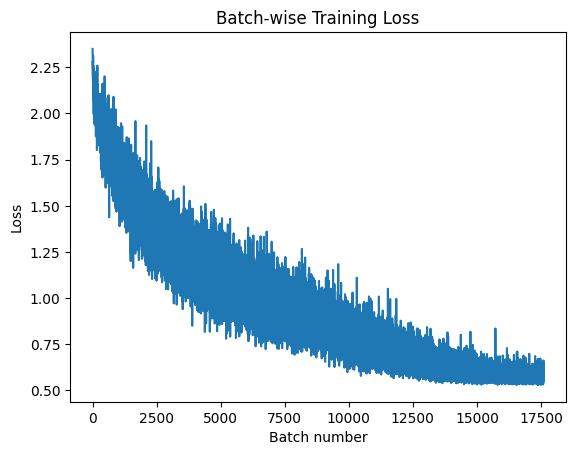

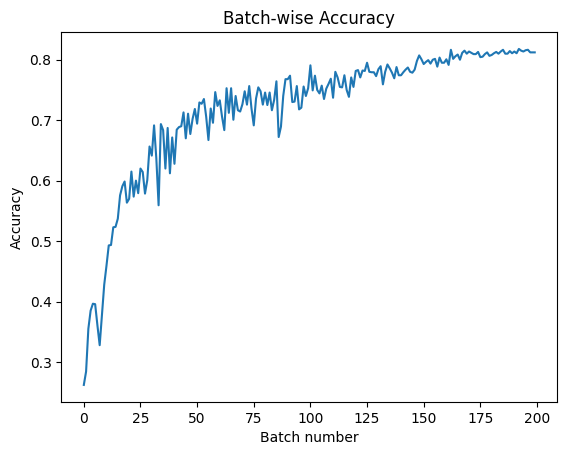

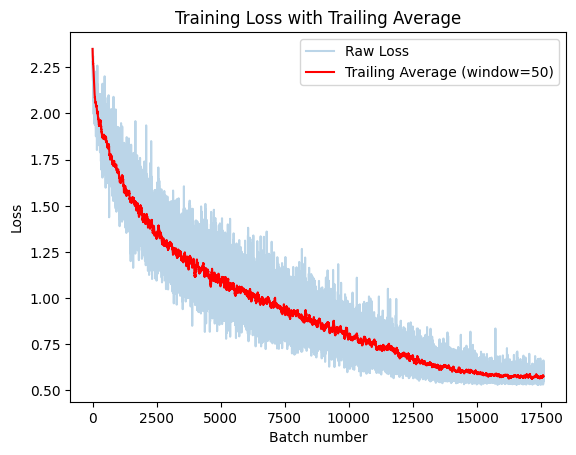

epoch 0: 0.20642857142857143
epoch 1: 0.225
epoch 2: 0.27785714285714286
epoch 3: 0.29642857142857143
epoch 4: 0.35214285714285715
epoch 5: 0.33214285714285713
epoch 6: 0.35928571428571426
epoch 7: 0.415
epoch 8: 0.4057142857142857
epoch 9: 0.42714285714285716
epoch 10: 0.42714285714285716
epoch 11: 0.4942857142857143
epoch 12: 0.44785714285714284
epoch 13: 0.4442857142857143
epoch 14: 0.49
epoch 15: 0.4714285714285714
epoch 16: 0.5571428571428572
epoch 17: 0.5771428571428572
epoch 18: 0.5821428571428572
epoch 19: 0.495
epoch 20: 0.5757142857142857
epoch 21: 0.6171428571428571
epoch 22: 0.6071428571428571
epoch 23: 0.5478571428571428
epoch 24: 0.6042857142857143
epoch 25: 0.5857142857142857
epoch 26: 0.5964285714285714
epoch 27: 0.6285714285714286
epoch 28: 0.5971428571428572
epoch 29: 0.63
epoch 30: 0.6414285714285715
epoch 31: 0.655
epoch 32: 0.6535714285714286
epoch 33: 0.6885714285714286
epoch 34: 0.6407142857142857
epoch 35: 0.6814285714285714
epoch 36: 0.66
epoch 37: 0.6114285714

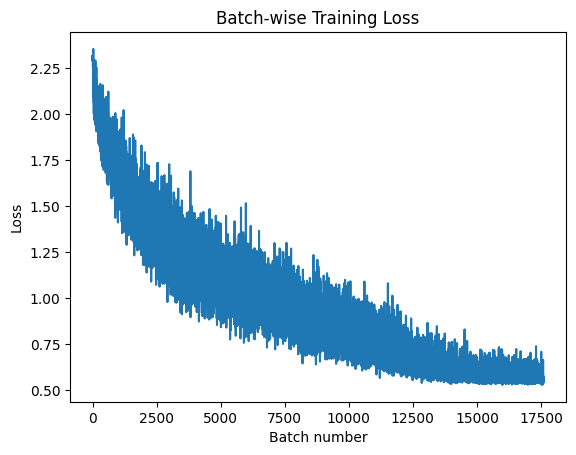

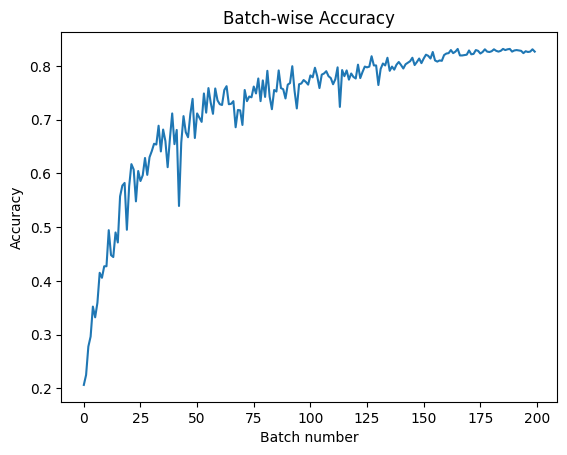

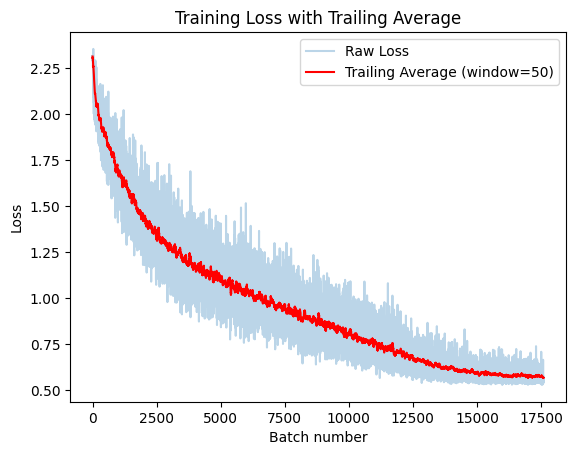

epoch 0: 0.2621428571428571
epoch 1: 0.28714285714285714
epoch 2: 0.32785714285714285
epoch 3: 0.29714285714285715
epoch 4: 0.32357142857142857
epoch 5: 0.3492857142857143
epoch 6: 0.4392857142857143
epoch 7: 0.41
epoch 8: 0.3757142857142857
epoch 9: 0.45285714285714285
epoch 10: 0.4878571428571429
epoch 11: 0.4785714285714286
epoch 12: 0.5014285714285714
epoch 13: 0.5057142857142857
epoch 14: 0.5614285714285714
epoch 15: 0.5507142857142857
epoch 16: 0.5185714285714286
epoch 17: 0.5578571428571428
epoch 18: 0.5785714285714286
epoch 19: 0.5414285714285715
epoch 20: 0.5957142857142858
epoch 21: 0.6028571428571429
epoch 22: 0.5807142857142857
epoch 23: 0.6342857142857142
epoch 24: 0.635
epoch 25: 0.5228571428571429
epoch 26: 0.6592857142857143
epoch 27: 0.6428571428571429
epoch 28: 0.6614285714285715
epoch 29: 0.6321428571428571
epoch 30: 0.6257142857142857
epoch 31: 0.6257142857142857
epoch 32: 0.6407142857142857
epoch 33: 0.6385714285714286
epoch 34: 0.5371428571428571
epoch 35: 0.64642

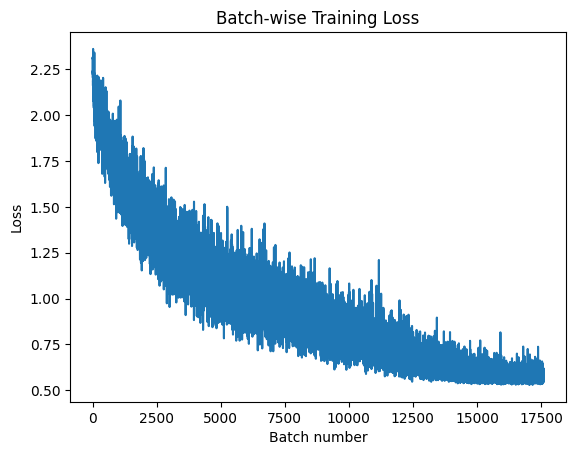

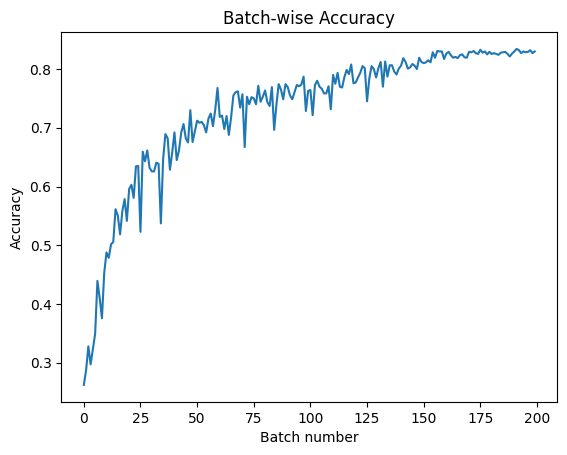

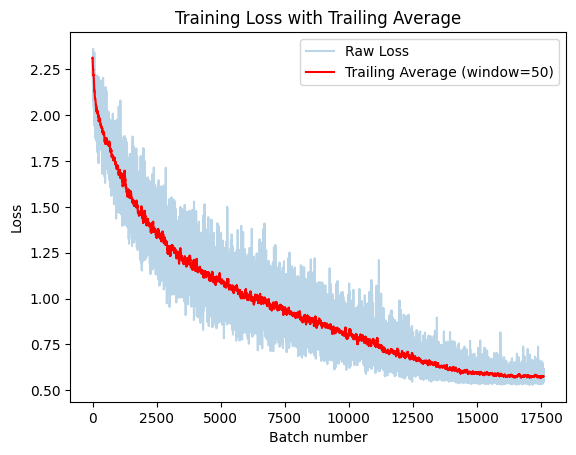

epoch 0: 0.24571428571428572
epoch 1: 0.29642857142857143
epoch 2: 0.26857142857142857
epoch 3: 0.34785714285714286
epoch 4: 0.29
epoch 5: 0.4421428571428571
epoch 6: 0.42
epoch 7: 0.32785714285714285
epoch 8: 0.45714285714285713
epoch 9: 0.4635714285714286
epoch 10: 0.5185714285714286
epoch 11: 0.42214285714285715
epoch 12: 0.44285714285714284
epoch 13: 0.495
epoch 14: 0.5021428571428571
epoch 15: 0.6164285714285714
epoch 16: 0.5335714285714286
epoch 17: 0.5542857142857143
epoch 18: 0.605
epoch 19: 0.6135714285714285
epoch 20: 0.5085714285714286
epoch 21: 0.5814285714285714
epoch 22: 0.6028571428571429
epoch 23: 0.6007142857142858
epoch 24: 0.6278571428571429
epoch 25: 0.6228571428571429
epoch 26: 0.65
epoch 27: 0.6228571428571429
epoch 28: 0.6471428571428571
epoch 29: 0.6621428571428571
epoch 30: 0.5792857142857143
epoch 31: 0.7085714285714285
epoch 32: 0.7042857142857143
epoch 33: 0.6721428571428572
epoch 34: 0.6564285714285715
epoch 35: 0.6714285714285714
epoch 36: 0.64857142857142

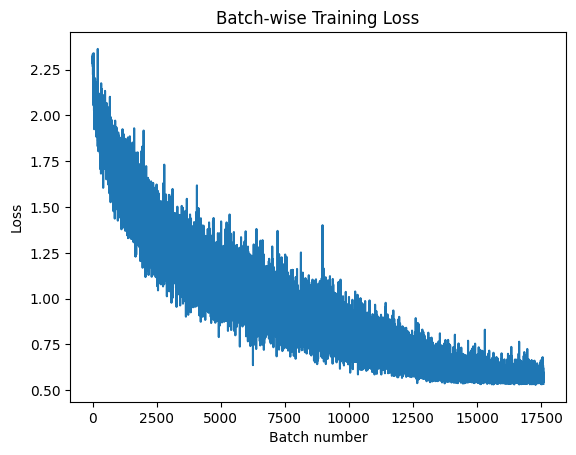

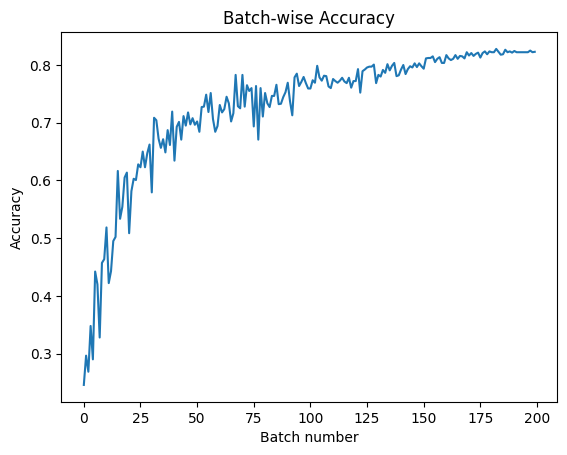

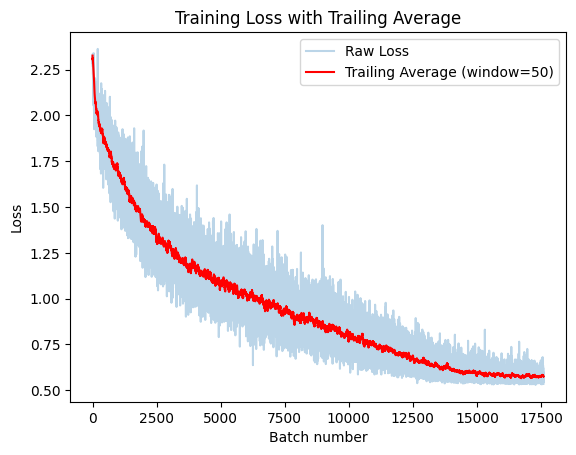

epoch 0: 0.23285714285714285
epoch 1: 0.27285714285714285
epoch 2: 0.29285714285714287
epoch 3: 0.30714285714285716
epoch 4: 0.3342857142857143
epoch 5: 0.32785714285714285
epoch 6: 0.3757142857142857
epoch 7: 0.3921428571428571
epoch 8: 0.43642857142857144
epoch 9: 0.45357142857142857
epoch 10: 0.43714285714285717
epoch 11: 0.42428571428571427
epoch 12: 0.43857142857142856
epoch 13: 0.4714285714285714
epoch 14: 0.5307142857142857
epoch 15: 0.47
epoch 16: 0.5192857142857142
epoch 17: 0.5507142857142857
epoch 18: 0.5607142857142857
epoch 19: 0.5464285714285714
epoch 20: 0.5957142857142858
epoch 21: 0.5478571428571428
epoch 22: 0.5835714285714285
epoch 23: 0.61
epoch 24: 0.5721428571428572
epoch 25: 0.6057142857142858
epoch 26: 0.5557142857142857
epoch 27: 0.5807142857142857
epoch 28: 0.595
epoch 29: 0.5835714285714285
epoch 30: 0.6164285714285714
epoch 31: 0.6528571428571428
epoch 32: 0.6057142857142858
epoch 33: 0.6571428571428571
epoch 34: 0.6671428571428571
epoch 35: 0.70071428571428

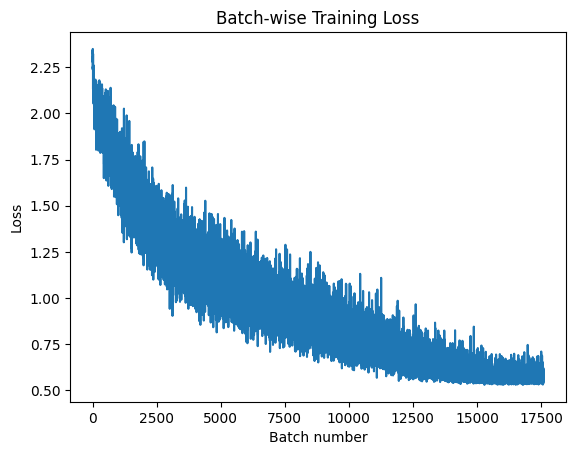

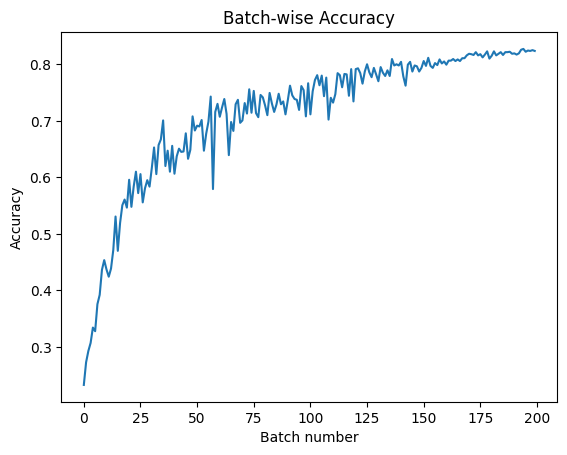

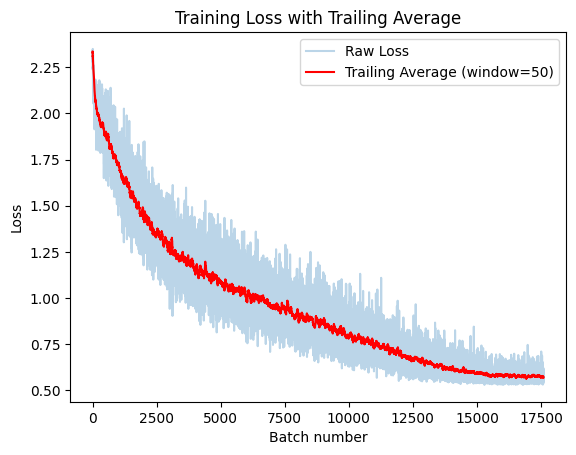

In [ ]:
#split training data
df = pd.read_csv('/content/drive/MyDrive/train_labels.csv')
trainpath = '/content/drive/MyDrive/train/'
dataset = TrainingDataset(df, trainpath, True) #initiate Dataset
no_aug = TrainingDataset(df, trainpath, False)

indices = list(range(len(dataset)))
train_indices, test_indices = train_test_split(indices, test_size=0.3, random_state=42)
final_test_dataset = Subset(no_aug, test_indices) #for final model performance analysis

fold_accuracy = []
kf = KFold(shuffle=True, random_state=42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for i, (train_idx, test_idx) in enumerate(kf.split(train_indices)):
  cnn = CNN()
  cnn.to(device)
  loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)
  optimizer = optim.SGD(cnn.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4)
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

  kf_train_dataset = Subset(dataset, [train_indices[j] for j in train_idx])
  kf_train_dataloader = DataLoader(kf_train_dataset, batch_size=64, shuffle=True, num_workers=2)

  kf_test_dataset = Subset(no_aug, [train_indices[j] for j in test_idx])
  kf_test_dataloader = DataLoader(kf_test_dataset, batch_size=64, shuffle=False, num_workers=2)

  training_loss = []
  validation_loss=[]
  epoch_accuracy = []

  for epoch in range(200):
    for input, label in kf_train_dataloader: #training loop per epoch
      cnn.train()
      input = input.to(device)
      label = label.to(device)
      output = cnn(input)
      loss = loss_function(output, label)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      training_loss.append(loss.item())
    cnn.eval()
    with torch.no_grad():
      correct = 0
      for input, label in kf_test_dataloader:
        input = input.to(device)
        label = label.to(device)
        output = cnn(input)
        prediction = output.argmax(dim=1)
        correct += (prediction == label).sum().item()
      accuracy = correct/len(test_idx)
      epoch_accuracy.append(accuracy)
      scheduler.step()
      print(f"epoch {epoch}: {accuracy}")

  #fold accuracy
  cnn.eval()
  with torch.no_grad():
      correct = 0
      for input, label in kf_test_dataloader:
        input = input.to(device)
        label = label.to(device)
        output = cnn(input)
        prediction = output.argmax(dim=1)
        correct += (prediction == label).sum().item()
      accuracy = correct/len(test_idx)
      fold_accuracy.append(accuracy)
      print(fold_accuracy)

  plt.plot(training_loss)
  plt.xlabel("Batch number")
  plt.ylabel("Loss")
  plt.title("Batch-wise Training Loss")
  plt.savefig(f"/content/drive/MyDrive/551/cnn_fold_batchloss{i+1}.png")
  plt.show()

  plt.plot(epoch_accuracy)
  plt.xlabel("Batch number")
  plt.ylabel("Accuracy")
  plt.title("Batch-wise Accuracy")
  plt.savefig(f"/content/drive/MyDrive/551/cnn_fold_accuracy{i+1}.png")
  plt.show()

  fold_filename = f"/content/drive/MyDrive/551/cnn_fold_{i+1}.pth"
  torch.save(cnn.state_dict(), fold_filename)

  smoothed_loss = moving_average(training_loss, 50)

  plt.plot(training_loss, alpha=0.3, label='Raw Loss')
  plt.plot(smoothed_loss, color='red', label=f'Trailing Average (window={50})')
  plt.xlabel("Batch number")
  plt.ylabel("Loss")
  plt.title("Training Loss with Trailing Average")
  plt.legend()
  plt.savefig(f"/content/drive/MyDrive/551/cnn_fold_smoothed{i+1}.png")
  plt.show()

## CNN Full Dataset Training and Final Evaluation

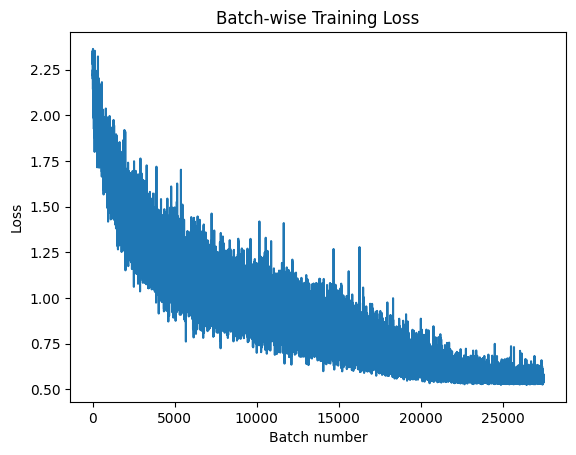

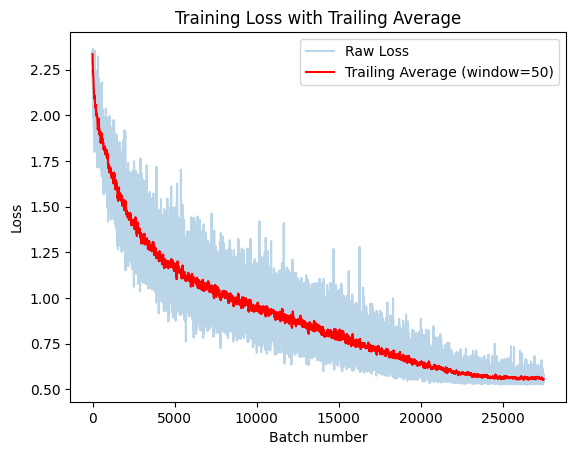

<Figure size 640x480 with 0 Axes>

In [ ]:
#Final Training

#split training data
train_dataset = Subset(dataset, train_indices)
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
final_test_dataset = Subset(no_aug, test_indices) #for final model performance analysis
test_dataloader = DataLoader(final_test_dataset, batch_size=1, shuffle=False, num_workers=2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

cnn = CNN()
cnn.to(device)
loss_function = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.SGD(cnn.parameters(), lr=0.05, momentum=0.9, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=250)

training_loss = []
validation_loss=[]
epoch_accuracy = []

for epoch in range(250):
  for input, label in train_dataloader: #training loop per epoch
    cnn.train()
    input = input.to(device)
    label = label.to(device)
    output = cnn(input)
    loss = loss_function(output, label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    training_loss.append(loss.item())
  scheduler.step()

plt.plot(training_loss)
plt.xlabel("Batch number")
plt.ylabel("Loss")
plt.title("Batch-wise Training Loss")
plt.savefig(f"/content/drive/MyDrive/cnn_final_batchloss.png")
plt.show()

torch.save(cnn.state_dict(), "/content/drive/MyDrive/cnn_final.pth")

smoothed_loss = moving_average(training_loss, 50)

plt.plot(training_loss, alpha=0.3, label='Raw Loss')
plt.plot(smoothed_loss, color='red', label=f'Trailing Average (window={50})')
plt.xlabel("Batch number")
plt.ylabel("Loss")
plt.title("Training Loss with Trailing Average")
plt.legend()
plt.savefig(f"/content/drive/MyDrive/cnn_final_smoothed.png")
plt.show()

In [ ]:

final_accuracy = []
truck = []
deer = []
bird = []
frog = []
ship = []
horse = []
cat = []
dog = []
automobile = []
airplane = []

labels_dict = {
    0: truck,
    1: deer,
    2: bird,
    3: frog,
    4: ship,
    5: horse,
    6: cat,
    7: dog,
    8: automobile,
    9: airplane}

correct = 0
cnn.eval()
for input, label in test_dataloader:
  with torch.no_grad():
    input = input.to(device)
    label = label.to(device)
    output = cnn(input)
    prediction = output.argmax(dim=1)
    if prediction == label:
      correct += 1
      labels_dict[prediction.item()].append(1)
    else:
      labels_dict[prediction.item()].append(0)
accuracy = correct/len(test_indices)
print("Final Overall Accuracy: "+str(accuracy))

Final Overall Accuracy: 0.8356666666666667


In [ ]:
print("truck accuracy: " + str(sum(truck)/len(truck)))
print("deer accuracy: " + str(sum(deer)/len(deer)))
print("bird accuracy: " + str(sum(bird)/len(bird)))
print("frog accuracy: " + str(sum(frog)/len(frog)))
print("ship accuracy: " + str(sum(ship)/len(ship)))
print("horse accuracy: " + str(sum(horse)/len(horse)))
print("cat accuracy: " + str(sum(cat)/len(cat)))
print("dog accuracy: " + str(sum(dog)/len(dog)))
print("automobile accuracy: " + str(sum(automobile)/len(automobile)))
print("airplane accuracy: " + str(sum(airplane)/len(airplane)))

Truck accuracy: 0.8957055214723927
deer accuracy: 0.8226950354609929
bird accuracy: 0.7951807228915663
frog accuracy: 0.8715277777777778
ship accuracy: 0.911864406779661
horse accuracy: 0.836676217765043
cat accuracy: 0.710801393728223
dog accuracy: 0.7231270358306189
automobile accuracy: 0.9216300940438872
airplane accuracy: 0.8489932885906041


CNN Prediction for Kaggle

In [ ]:
kaggle_cnn = CNN()
kaggle_cnn.load_state_dict(torch.load('/content/drive/MyDrive/cnn_final.pth'))
# kaggle_cnn.load_state_dict(torch.load("best_accuracy.pth"))
kaggle_cnn.eval()

testpath = '/content/drive/MyDrive/test/'
kaggle_df = pd.read_csv('/content/drive/MyDrive/kaggle.csv')
kaggle_transform = transforms.Compose([
        transforms.ToTensor(), #converts a PIL image to a Pytorch Tensor
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
labels_dict = {
    0: "truck",
    1: "deer",
    2: "bird",
    3: "frog",
    4: "ship",
    5: "horse",
    6: "cat",
    7: "dog",
    8: "automobile",
    9: "airplane"}

for i, row in kaggle_df.iterrows():
  img = Image.open(testpath+row["id"])
  img = img.convert("RGB")
  img = kaggle_transform(img).unsqueeze(0)
  with torch.no_grad():
        output = kaggle_cnn(img)
        prediction = output.argmax(dim=1).item()
  kaggle_df.iloc[i, 1] = labels_dict[prediction]
  print(str(i)+": "+str(prediction))

kaggle_df.to_csv("/content/drive/MyDrive/kaggle.csv", index=False)



0: 6
1: 0
2: 5
3: 9
4: 8
5: 2
6: 5
7: 1
8: 8
9: 8
10: 8
11: 0
12: 2
13: 1
14: 7
15: 4
16: 0
17: 8
18: 8
19: 0
20: 3
21: 5
22: 1
23: 9
24: 9
25: 2
26: 0
27: 9
28: 9
29: 1
30: 3
31: 8
32: 5
33: 9
34: 3
35: 5
36: 6
37: 7
38: 1
39: 7
40: 7
41: 2
42: 6
43: 5
44: 8
45: 1
46: 6
47: 8
48: 7
49: 8
50: 2
51: 5
52: 1
53: 9
54: 5
55: 9
56: 0
57: 9
58: 0
59: 9
60: 8
61: 5
62: 8
63: 7
64: 8
65: 5
66: 0
67: 6
68: 7
69: 4
70: 9
71: 0
72: 3
73: 6
74: 4
75: 3
76: 0
77: 7
78: 1
79: 7
80: 3
81: 8
82: 8
83: 5
84: 0
85: 8
86: 0
87: 4
88: 0
89: 0
90: 4
91: 6
92: 9
93: 6
94: 0
95: 7
96: 9
97: 4
98: 5
99: 8
100: 4
101: 7
102: 2
103: 7
104: 6
105: 1
106: 4
107: 8
108: 5
109: 6
110: 8
111: 1
112: 3
113: 9
114: 1
115: 0
116: 9
117: 0
118: 3
119: 4
120: 6
121: 9
122: 8
123: 4
124: 3
125: 2
126: 3
127: 8
128: 8
129: 1
130: 3
131: 0
132: 7
133: 7
134: 3
135: 9
136: 1
137: 5
138: 9
139: 3
140: 4
141: 9
142: 3
143: 9
144: 8
145: 3
146: 5
147: 5
148: 5
149: 2
150: 4
151: 7
152: 5
153: 7
154: 8
155: 4
156: 0
157: 0
158:

# Task 1 - Vision Transformer

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


Imports and Utility Functions

In [ ]:
# imports
import os, time, math, random, gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.cuda.amp import autocast, GradScaler # For T4 GPU speedup

# copy data to local ssd
LOCAL_DATA_DIR = "/content/local_data"
LOCAL_TRAIN_IMAGES = os.path.join(LOCAL_DATA_DIR, "train")
LOCAL_TEST_IMAGES  = os.path.join(LOCAL_DATA_DIR, "test")
print("Starting local data copy (This may take 1-2 minutes)...")
os.makedirs(LOCAL_DATA_DIR, exist_ok=True) #create lcoal directory

# paths
!cp -r $TRAIN_IMAGES $LOCAL_DATA_DIR
!cp -r $TEST_IMAGES $LOCAL_DATA_DIR
print("Data copy complete. Updating global paths for fast I/O.")

global TRAIN_IMAGES
global TEST_IMAGES
TRAIN_IMAGES = LOCAL_TRAIN_IMAGES
TEST_IMAGES = LOCAL_TEST_IMAGES

DRIVE_ROOT = "/content/drive/MyDrive"
TRAIN_IMAGES = os.path.join(DRIVE_ROOT, "train")
TEST_IMAGES  = os.path.join(DRIVE_ROOT, "test")
TRAIN_LABELS_CSV = os.path.join(DRIVE_ROOT, "train_labels.csv")
SAMPLE_SUB = os.path.join(DRIVE_ROOT, "sample_submission.csv")
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, "ecse551_task1_checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


Starting local data copy (This may take 1-2 minutes)...
cp: missing file operand
Try 'cp --help' for more information.
cp: missing file operand
Try 'cp --help' for more information.
Data copy complete. Updating global paths for fast I/O.


Dataset and transforms

In [ ]:
# label mapping (same as CNN)
label2idx = {
    "truck": 0,
    "deer": 1,
    "bird": 2,
    "frog": 3,
    "ship": 4,
    "horse": 5,
    "cat": 6,
    "dog": 7,
    "automobile": 8,
    "airplane": 9
}
idx2label = {v:k for k,v in label2idx.items()}

IMAGE_SIZE = 32

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

class Dataset551(Dataset):
    """Training dataset: reads train_labels.csv and images in train"""
    def __init__(self, labels_csv=TRAIN_LABELS_CSV, image_dir=TRAIN_IMAGES, transform=None):
        self.df = pd.read_csv(labels_csv)
        self.image_dir = image_dir
        self.transform = transform
        self.label2idx = label2idx
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['id'])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.label2idx[row['label']]
        return img, label

class Test551(Dataset):
    """Test dataset for submission: uses sample_submission.csv as id list"""
    def __init__(self, sample_csv=SAMPLE_SUB, image_dir=TEST_IMAGES, transform=val_transform):
        self.df = pd.read_csv(sample_csv)
        self.image_dir = image_dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_id = self.df.at[idx, 'id']
        img_path = os.path.join(self.image_dir, img_id)
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, img_id

Helper functions

In [ ]:
def save_ckpt(state, path):
    torch.save(state, path)

def load_ckpt(path, model, optimizer=None, map_location='cpu'):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt['model_state_dict'])
    if optimizer and 'optimizer_state_dict' in ckpt:
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    return ckpt

def train_one_epoch(model, loader, optimizer, criterion, scaler=None, device=None, accumulation_steps=1):
    # Training implementation
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Gradient Accumulation setup
    optimizer.zero_grad(set_to_none=True)

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        # Forward pass (using AMP)
        if scaler is not None:
            with autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            # Normalize loss by accumulation steps and scale it
            loss = loss / accumulation_steps
            scaler.scale(loss).backward()

        else:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss = loss / accumulation_steps
            loss.backward()

        # Update weights every 'accumulation_steps'
        if (batch_idx + 1) % accumulation_steps == 0 or (batch_idx + 1) == len(loader):
            if scaler is not None:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * imgs.size(0) * accumulation_steps # Multiply loss back up
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def validate(model, loader, criterion, device=None):
    # Validation implementation (No change needed)
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total

ViT Class Definitions:

1. Patch embedding layer
2. Multiclass self attenuation
3. Transformer encoder block
4. ViT Model

In [ ]:
# 1. Patch embedding layer
class PatchEmbed(nn.Module):
    """Splits image into non-overlapping patches and applies inear projection.
    Input: (B, C, H, W) -> Output: (B, num_patches, embed_dim)"""

    def __init__(self, img_size=32, patch_size=4, in_chans=3, embed_dim=192):
        super().__init__()
        # Check if patch size divides image size evenly
        assert img_size % patch_size == 0, "img_size must be divisible by patch_size"

        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2  # e.g., (32/4)^2 = 64
        patch_dim = in_chans * patch_size * patch_size  # e.g., 3*4*4 = 48

        # Linear projection layer (equivalent to a 1x1 Conv with stride=patch_size)
        self.proj = nn.Linear(patch_dim, embed_dim)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size

        # 1. Patchify: Use unfold to extract non-overlapping patches
        # Output shape: (B, C, H/p, W/p, p, p)
        x = x.unfold(2, p, p).unfold(3, p, p)

        # 2. Re-arrange and flatten C*p*p into the last dimension
        # (B, H/p, W/p, C, p, p) -> (B, num_patches, patch_dim)
        x = x.permute(0, 2, 3, 1, 4, 5).contiguous()
        x = x.view(B, -1, C * p * p)  # (B, 64, 48)

        # 3. Linear Projection to Embedding Dimension
        x = self.proj(x)  # (B, 64, D=192)
        return x

# 2. Multi-head self-attenuation
class MultiHeadSelfAttention(nn.Module):
    """Implements scaled dot product attention across multiple heads in parallel.
    Uses nn.Linear for QKV projections"""
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        # Check for splitting the embedding dimension
        assert embed_dim % num_heads == 0, "embed_dim must be divisible by num_heads"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads  # Dimension per head, e.g., 192/6 = 32
        self.scale = self.head_dim ** -0.5       # Scaling factor $1/\sqrt{d_k}$
        # Combined linear projection for Q, K, V
        self.qkv = nn.Linear(embed_dim, embed_dim * 3, bias=False)
        self.proj = nn.Linear(embed_dim, embed_dim) # Final projection after concatenation
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, D = x.shape # N is sequence length (1 + num_patches)

        # 1. Project and split QKV: (B, N, 3D) -> (B, N, 3, heads, head_dim) -> (3, B, heads, N, head_dim)
        qkv = self.qkv(x)
        qkv = qkv.reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]  # Each is (B, heads, N, head_dim)
        # 2. Scaled Dot-Product Attention: attn = (Q @ K^T) * scale
        attn = (q @ k.transpose(-2, -1)) * self.scale
        # 3. Softmax to get attention weights $\alpha_i$
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)
        # 4. Multiply with Values and concatenate: out = attn @ V
        out = (attn @ v)
        out = out.transpose(1, 2).reshape(B, N, D) # (B, N, D)
        # 5. Final linear projection
        out = self.proj(out)
        out = self.proj_drop(out)
        return out


# 3. Transformer encoder block
class TransformerEncoderBlock(nn.Module):
    """
    Single ViT Encoder Block: LayerNorm -> MHA -> Residual -> LayerNorm -> FFN -> Residual
    """
    def __init__(self, embed_dim=192, num_heads=6, mlp_ratio=4.0, dropout=0.2):
        super().__init__()
        # MHA Sub-layer with LayerNorm
        self.norm1 = nn.LayerNorm(embed_dim)
        self.mha = MultiHeadSelfAttention(embed_dim, num_heads, dropout=dropout)
        # FFN Sub-layer with LayerNorm
        self.norm2 = nn.LayerNorm(embed_dim)
        hidden_dim = int(embed_dim * mlp_ratio) # FFN hidden dimension

        # Positionwise FFN
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.GELU(), # Use GELU activation
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, embed_dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.mha(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x


# 4. ViT Model
class ViT(nn.Module):
    """Vision Transformer for image classification"""
    def __init__(self, img_size=32, patch_size=4, in_chans=3, num_classes=10,
                 embed_dim=192, depth=6, num_heads=6, mlp_ratio=4.0, dropout=0.2):
        super().__init__()
        # 1. Patch Embedding
        self.patch_embed = PatchEmbed(img_size=img_size, patch_size=patch_size,
                                      in_chans=in_chans, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches
        # 2. Classification Token (<cls> token)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # 3. Positional Embedding (Learnable)
        self.pos_embed = nn.Parameter(torch.zeros(1, 1 + num_patches, embed_dim))
        self.pos_drop = nn.Dropout(p=dropout)
        # 4. Transformer Encoder Stack
        self.blocks = nn.ModuleList([
            TransformerEncoderBlock(embed_dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, dropout=dropout)
            for _ in range(depth)
        ])
        # 5. Final Normalization and MLP Head
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

        # Weight Initialization
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.zeros_(m.bias)
                nn.init.ones_(m.weight)

    def forward(self, x):
        # x: (B, C, H, W)
        B = x.shape[0]
        x = self.patch_embed(x)                   # (B, num_patches, D)
        cls_tokens = self.cls_token.expand(B, -1, -1)  # (B, 1, D)
        x = torch.cat((cls_tokens, x), dim=1)          # (B, 1 + num_patches, D)
        x = x + self.pos_embed
        x = self.pos_drop(x)
        for blk in self.blocks:
            x = blk(x)
        # Extract the first token (the CLS token) for classification
        cls_output = self.norm(x[:, 0])
        logits = self.head(cls_output)
        return logits

ViT Training Configuration/Setup

In [ ]:
# Hyperparameters: Configuration for 32x32 images
VIT_CONFIG = {
    "img_size": 32,
    "in_chans": 3,
    "num_classes": 10,
    "patch_size": 4,  # 64 patches = N sequence length
    "embed_dim": 256,
    "depth": 8,
    "num_heads": 8,   # embed_dim % num_heads == 0 (356/8 =32)
    "batch_size": 64,
    "lr": 3e-4,
    "dropout": 0.2,
    "mlp_ratio": 4.0,
    "num_epochs": 100
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- Running ViT Training on {device} ---")

# Create subsets based on the 70/30 train/test split (from CNN code)
df = pd.read_csv(TRAIN_LABELS_CSV)
labels = df['label'].map(label2idx).values
indices = np.arange(len(labels))
train_indices, holdout_indices = train_test_split(indices, test_size=0.30, random_state=42)

# Full training set with augmentation (70%)
full_train_dataset = Subset(Dataset551(transform=train_transform), train_indices)
train_loader = DataLoader(full_train_dataset, batch_size=VIT_CONFIG['batch_size'], shuffle=True, num_workers=0, pin_memory=True)

# Validation/Holdout set without augmentation (30%)
full_holdout_dataset = Subset(Dataset551(transform=val_transform), holdout_indices)
holdout_loader = DataLoader(full_holdout_dataset, batch_size=VIT_CONFIG['batch_size'], shuffle=False, num_workers=0, pin_memory=True)

# --- Separate Model Params & Initialize ---
model_params = {
    'img_size': VIT_CONFIG['img_size'],
    'patch_size': VIT_CONFIG['patch_size'],
    'in_chans': VIT_CONFIG.get('in_chans', 3),
    'num_classes': VIT_CONFIG.get('num_classes', 10),
    'embed_dim': VIT_CONFIG['embed_dim'],
    'depth': VIT_CONFIG['depth'],
    'num_heads': VIT_CONFIG['num_heads'],
    'mlp_ratio': VIT_CONFIG['mlp_ratio'],
    'dropout': VIT_CONFIG['dropout']
}

# Initialize model using ONLY model architecture parameters
model_vit = ViT(**model_params).to(device)

# --- Initialize Optimizer, Scheduler, Loss ---
optimizer = optim.AdamW(model_vit.parameters(), lr=VIT_CONFIG['lr'], weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=VIT_CONFIG['num_epochs'])
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

print(f"Model Parameters: {sum(p.numel() for p in model_vit.parameters() if p.requires_grad):,}")
print(f"Starting training for {VIT_CONFIG['num_epochs']} epochs...")


NameError: name 'torch' is not defined

## ViT Training Loop (with performance eval)

/tmp/ipython-input-1419296195.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/100 | Train Acc: 0.2033 | Holdout Acc: 0.2293 | Holdout Loss: 2.0859
Epoch 2/100 | Train Acc: 0.2476 | Holdout Acc: 0.2773 | Holdout Loss: 1.9843
Epoch 3/100 | Train Acc: 0.2614 | Holdout Acc: 0.2797 | Holdout Loss: 2.0066
Epoch 4/100 | Train Acc: 0.2971 | Holdout Acc: 0.3320 | Holdout Loss: 1.9373
Epoch 5/100 | Train Acc: 0.3124 | Holdout Acc: 0.3147 | Holdout Loss: 1.9333
Epoch 6/100 | Train Acc: 0.3189 | Holdout Acc: 0.3387 | Holdout Loss: 1.8710
Epoch 7/100 | Train Acc: 0.3240 | Holdout Acc: 0.3517 | Holdout Loss: 1.8476
Epoch 8/100 | Train Acc: 0.3364 | Holdout Acc: 0.3540 | Holdout Loss: 1.8716
Epoch 9/100 | Train Acc: 0.3536 | Holdout Acc: 0.3543 | Holdout Loss: 1.8836
Epoch 10/100 | Train Acc: 0.3690 | Holdout Acc: 0.3667 | Holdout Loss: 1.8643
Epoch 11/100 | Train Acc: 0.3777 | Holdout Acc: 0.3723 | Holdout Loss: 1.8545
Epoch 12/100 | Train Acc: 0.3797 | Holdout Acc: 0.4093 | Holdout Loss: 1.7779
Epoch 13/100 | Train Acc: 0.4010 | Holdout Acc: 0.4107 | Holdout Loss: 1.

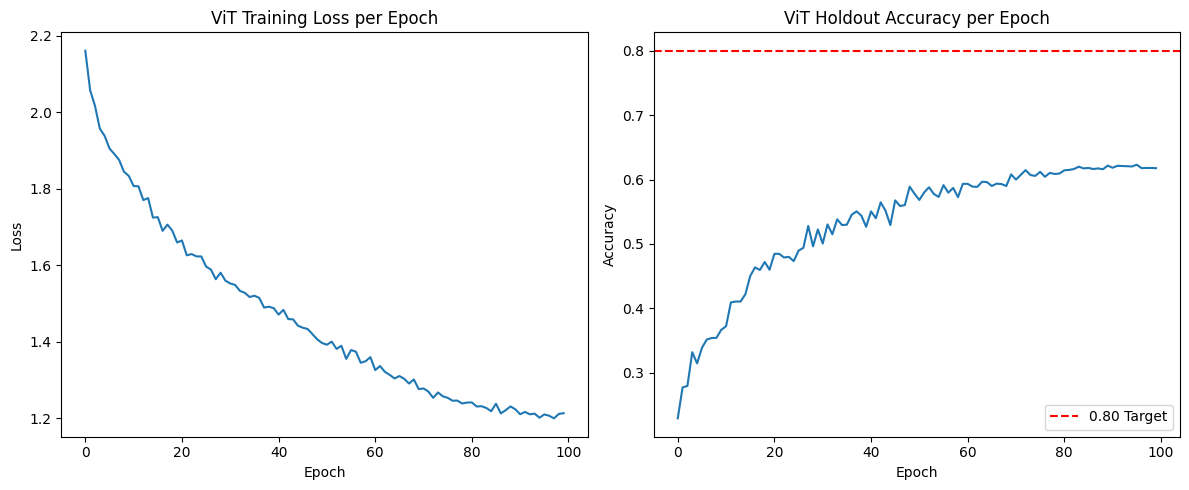

In [ ]:
best_holdout_acc = 0.0
history = {"train_loss":[], "hold_acc":[]}

for epoch in range(1, VIT_CONFIG['num_epochs'] + 1):
    # --- Train ---
    t_loss, t_acc = train_one_epoch(model_vit, train_loader, optimizer, criterion, scaler=scaler, device=device, accumulation_steps=4)

    # --- Validate ---
    h_loss, h_acc = validate(model_vit, holdout_loader, criterion, device=device)

    scheduler.step() # Step LR scheduler

    # --- Record History ---
    history["train_loss"].append(t_loss)
    history["hold_acc"].append(h_acc)

    # --- Output Progress ---
    print(f"Epoch {epoch}/{VIT_CONFIG['num_epochs']} | Train Acc: {t_acc:.4f} | Holdout Acc: {h_acc:.4f} | Holdout Loss: {h_loss:.4f}")

    # --- Save Best Checkpoint (Based on Validation Accuracy) ---
    if h_acc > best_holdout_acc:
        best_holdout_acc = h_acc
        ckpt_path = os.path.join(CHECKPOINT_DIR, "vit_best_model.pth")
        save_ckpt({'epoch': epoch, 'model_state_dict': model_vit.state_dict(), 'config': VIT_CONFIG, 'hold_acc': h_acc}, ckpt_path)

print(f"\nFinal Best Holdout Accuracy: {best_holdout_acc:.4f}")

# Save the final model state
final_path = os.path.join(CHECKPOINT_DIR, "vit_final.pth")
save_ckpt({'epoch': VIT_CONFIG['num_epochs'], 'model_state_dict': model_vit.state_dict(), 'config': VIT_CONFIG}, final_path)
print("Saved final model for prediction (vit_final.pth)")

# --- Performance Demonstration: Plotting ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'])
plt.title('ViT Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(history['hold_acc'])
plt.title('ViT Holdout Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.axhline(0.80, color='r', linestyle='--', label='0.80 Target')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_ROOT, "vit_performance_plot.png"))
plt.show()

Individual class accuracy testing

In [ ]:
from collections import defaultdict

# Load the Best ViT Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model_params = {
    'img_size': 32, 'patch_size': 4, 'in_chans': 3, 'num_classes': 10,
    'embed_dim': 256, 'depth': 8, 'num_heads': 8, 'mlp_ratio': 4.0, 'dropout': 0.2
}
model_vit_eval = ViT(**model_params).to(device)

best_ckpt_path = os.path.join(CHECKPOINT_DIR, "vit_best_model.pth")
load_ckpt(best_ckpt_path, model_vit_eval, map_location=device)
model_vit_eval.eval()

# map the predicted index back to the class name for reporting
class_names = list(label2idx.keys())
class_correct = defaultdict(int)
class_total = defaultdict(int)

# Run Evaluation Loop
print("--- Running ViT Per-Class Evaluation on Holdout Set ---")
total_correct = 0
total_samples = 0

with torch.no_grad():
    for imgs, labels in holdout_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model_vit_eval(imgs)
        _, predictions = outputs.max(1)

        # Calculate per-class stats
        for i in range(len(labels)):
            label = labels[i].item()
            pred = predictions[i].item()
            class_total[label] += 1
            if label == pred:
                class_correct[label] += 1
                total_correct += 1
        total_samples += labels.size(0)

# Results
overall_accuracy = total_correct / total_samples
print(f"\nOverall Holdout Accuracy: {overall_accuracy:.4f}\n")
print("Accuracy per Class:")
print("--------------------------------")

for i, class_name in enumerate(class_names):
    accuracy = class_correct[i] / class_total[i]
    print(f"{class_name.ljust(12)}: {accuracy:.4f} (Correct: {class_correct[i]} / Total: {class_total[i]})")

print("--------------------------------")

ViT Kaggle submission generation

In [ ]:
# Note: uses the VIT_CONFIG defined in the training section
model_submission = ViT(**model_params).to(device)

# Load the best weights based on validation accuracy
best_ckpt_path = os.path.join(CHECKPOINT_DIR, "vit_best_model.pth")
load_ckpt(best_ckpt_path, model_submission, map_location=device)
model_submission.eval()
print(f"Loaded best model from: {best_ckpt_path}")

# --- Data Loading for Unseen Test Set ---
class Test551(Dataset):
    """Test dataset for submission: uses sample_submission.csv as id list"""
    def __init__(self, sample_csv=os.path.join(DRIVE_ROOT, "sample_submission.csv"), image_dir=TEST_IMAGES, transform=val_transform):
        self.df = pd.read_csv(sample_csv)
        self.image_dir = image_dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img_id = self.df.at[idx, 'id']
        img_path = os.path.join(self.image_dir, img_id)
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, img_id

test_ds_kaggle = Test551(image_dir=TEST_IMAGES, transform=val_transform)
test_loader_kaggle = DataLoader(test_ds_kaggle, batch_size=128, shuffle=False, num_workers=2)

# --- Generate Predictions ---
predictions = []
ids = []

idx_to_label = {0: "truck", 1: "deer", 2: "bird", 3: "frog", 4: "ship", 5: "horse", 6: "cat", 7: "dog", 8: "automobile", 9: "airplane"}

with torch.no_grad():
    for imgs, img_ids in test_loader_kaggle:
        imgs = imgs.to(device)
        outputs = model_submission(imgs)
        _, preds = outputs.max(1)

        predictions.extend(preds.cpu().numpy())
        ids.extend(img_ids)

# --- Create and Save CSV ---
labels = [idx_to_label[int(p)] for p in predictions]
submission_df = pd.DataFrame({'id': ids, 'label': labels})
submission_df.sort_values(by='id', inplace=True) # Ensure correct ID order

submission_path = os.path.join(DRIVE_ROOT, "vit_kaggle_submission.csv")
submission_df.to_csv(submission_path, index=False)

# Save the model weights corresponding to the best accuracy
weights_path = os.path.join(DRIVE_ROOT, "vit_weights.pth")
torch.save(model_submission.state_dict(), weights_path)

print(f"\n--- Submission Details ---")
print(f"Total predictions generated: {len(submission_df)}")
print(f"Submission file saved to: {submission_path}")
print(f"Model weights saved to: {weights_path}")

Loaded best model from: /content/drive/MyDrive/ecse551_task1_checkpoints/vit_best_model.pth

--- Submission Details ---
Total predictions generated: 2000
Submission file saved to: /content/drive/MyDrive/vit_kaggle_submission.csv
Model weights saved to: /content/drive/MyDrive/vit_weights.pth


Task 1: Comparing CNN to ViT

# Task 2 - Free for All

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, Subset, DataLoader
from sklearn.model_selection import KFold
from PIL import Image
import os
import zipfile
from tqdm import tqdm
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torch.optim.lr_scheduler import CosineAnnealingLR
import copy
import json
from torch.cuda.amp import autocast, GradScaler

## Dataset Classes

In [ ]:
class Task2TrainingDataset224(Dataset):
    def __init__(self, data_path='/content/drive/MyDrive/data'):
        super().__init__()
        self.df = pd.read_csv(f'{data_path}/kaggle_challenge/train_labels.csv')
        self.trainpath = f'{data_path}/kaggle_challenge/train/'
        self.labels_dict = {
            "truck": 0, "deer": 1, "bird": 2, "frog": 3, "ship": 4,
            "horse": 5, "cat": 6, "dog": 7, "automobile": 8, "airplane": 9
        }
        self.transform = transforms.Compose([
            transforms.Resize(224),
            transforms.RandomHorizontalFlip(p=0.),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.trainpath + self.df.at[idx, "id"]
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        label_str = self.df.at[idx, "label"]
        label = self.labels_dict[label_str]
        return img, label



In [ ]:
class Task2TestDataset224(Dataset):
    def __init__(self, data_path='/content/drive/MyDrive/data'):
        super().__init__()
        self.df = pd.read_csv(f'{data_path}/kaggle_challenge/train_labels.csv')
        self.trainpath = f'{data_path}/kaggle_challenge/train/'
        self.labels_dict = {
            "truck": 0, "deer": 1, "bird": 2, "frog": 3, "ship": 4,
            "horse": 5, "cat": 6, "dog": 7, "automobile": 8, "airplane": 9
        }
        self.transform = transforms.Compose([
            transforms.Resize(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.trainpath + self.df.at[idx, "id"]
        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        label_str = self.df.at[idx, "label"]
        label = self.labels_dict[label_str]
        return img, label

In [ ]:
class Test551(Dataset):
    def __init__(self, data_path='/content/drive/MyDrive/data'):
        super().__init__()
        self.df = pd.read_csv(f'{data_path}/kaggle_challenge/sample_submission.csv')
        self.trainpath = f'{data_path}/kaggle_challenge/test/'
        self.transform = transforms.Compose([
            transforms.Resize(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        self.labels_dict = {
            "truck": 0, "deer": 1, "bird": 2, "frog": 3, "ship": 4,
            "horse": 5, "cat": 6, "dog": 7, "automobile": 8, "airplane": 9
        }

    def __getitem__(self, idx):
        img = Image.open(self.trainpath+self.df.at[idx, "id"])
        img = img.convert("RGB")
        img = self.transform(img)
        label = 0
        return img, label

    def __len__(self):
        return len(self.df)

In [ ]:
def create_efficientnet_b0(num_classes=10):
    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model = efficientnet_b0(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

## Task 2 Training with Cross-Validation

In [ ]:
# ================================================
# Task 2 Training with Cross-Validation (Colab)
# ================================================
from torch.cuda.amp import autocast, GradScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print("Device:", device)

# Datasets (10k labeled train)
train_dataset = Task2TrainingDataset224()
test_dataset  = Task2TestDataset224()   # same images, no augmentation

n_samples = len(train_dataset)
all_indices = np.arange(n_samples)
print("Total samples:", n_samples)

# Cross-validation config
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
num_epochs = 50
batch_size = 64
val_frequency = 2
num_workers = 2   # Colab: 2 workers is usually safe

fold_results = []
best_overall_acc = 0.0
best_model_state = None


def train_one_fold(train_idx, val_idx):
    """
    Trains EfficientNet-B0 on one CV fold.
    Returns: (best_val_acc, best_model_state_dict)
    """
    # Subsets
    train_subset = Subset(train_dataset, train_idx)
    val_subset   = Subset(test_dataset,  val_idx)

    # DataLoaders
    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )

    # Model, loss, optimizer, scheduler, AMP
    model = create_efficientnet_b0(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-5)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler = GradScaler()

    best_val_acc = 0.0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            with autocast():
                outputs = model(imgs)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        scheduler.step()

        # ---- Validation ----
        if (epoch + 1) % val_frequency == 0 or epoch + 1 == num_epochs:
            model.eval()
            correct = 0
            total = 0

            with torch.no_grad():
                for imgs, labels in val_loader:
                    imgs = imgs.to(device)
                    labels = labels.to(device)

                    outputs = model(imgs)
                    _, preds = outputs.max(1)
                    total += labels.size(0)
                    correct += (preds == labels).sum().item()

            val_acc = correct / total
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_state = copy.deepcopy(model.state_dict())

            print(
                f"Epoch {epoch+1}/{num_epochs} "
                f"| Loss={running_loss:.4f} "
                f"| Val Acc={val_acc:.4f} "
                f"| Best={best_val_acc:.4f}"
            )

    return best_val_acc, best_state


print("Starting 5-fold cross validation...\n")

for fold, (train_idx, val_idx) in enumerate(kfold.split(all_indices)):
    print(f"\n===== Fold {fold+1} =====")
    best_acc, model_state = train_one_fold(train_idx, val_idx)
    fold_results.append(best_acc)

    if best_acc > best_overall_acc:
        best_overall_acc = best_acc
        best_model_state = model_state
        torch.save(best_model_state, "/content/drive/MyDrive/task2_best_model.pth")
        print(f"Best model saved from Fold {fold+1}!")

print("\nResults per fold:", fold_results)
print("Mean CV accuracy:", np.mean(fold_results))
print("Best CV accuracy:", best_overall_acc)


Device: cpu
Total samples: 10000
Starting 5-fold cross validation...


===== Fold 1 =====


/tmp/ipython-input-3744219178.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/tmp/ipython-input-3744219178.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/amp/autocast_mode.py:270: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(


## Task 2 Results Saving

In [ ]:
# ======================================================
# Build Kaggle submission from best model (2000 test imgs)
# ======================================================
kaggle_test_dataset = Test551()  # uses data_path default
kaggle_test_loader = DataLoader(
    kaggle_test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_task2 = create_efficientnet_b0(num_classes=10).to(device)
model_task2.load_state_dict(torch.load('/content/drive/MyDrive/task2_best_model.pth'))
model_task2.eval()

idx_to_label = {
    0: "truck", 1: "deer", 2: "bird", 3: "frog", 4: "ship",
    5: "horse", 6: "cat", 7: "dog", 8: "automobile", 9: "airplane"
}

all_preds = []
all_ids = []

with torch.no_grad():
    for imgs, ids in kaggle_test_loader:
        imgs = imgs.to(device)
        outputs = model_task2(imgs)
        _, preds = outputs.max(1)
        preds = preds.cpu().numpy()

        all_ids.extend(ids)
        all_preds.extend([idx_to_label[int(p)] for p in preds])

submission_df = pd.DataFrame({"id": all_ids, "label": all_preds})
submission_df = submission_df.sort_values("id")
submission_df.to_csv("/content/drive/MyDrive/task2_kaggle_submission.csv", index=False)

print("Saved:", "/content/drive/MyDrive/task2_kaggle_submission.csv")


## Task 2 Kaggle Submission Generation

In [ ]:
# Load the test dataset for Kaggle submission
kaggle_test_dataset = Test551()
kaggle_test_loader = DataLoader(kaggle_test_dataset, batch_size=64, shuffle=False, num_workers=2)

# Load best model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_task2 = create_efficientnet_b0(num_classes=10)
model_task2.load_state_dict(torch.load('/content/drive/MyDrive/task2_best_model.pth'))
model_task2 = model_task2.to(device)
model_task2.eval()

# Reverse label dictionary for converting predictions to labels
idx_to_label = {0: "truck", 1: "deer", 2: "bird", 3: "frog", 4: "ship",
                5: "horse", 6: "cat", 7: "dog", 8: "automobile", 9: "airplane"}

# Generate predictions
predictions = []
ids = []

with torch.no_grad():
    for inputs, _ in tqdm(kaggle_test_loader, desc='Generating predictions'):
        inputs = inputs.to(device)
        outputs = model_task2(inputs)
        _, predicted = torch.max(outputs.data, 1)
        predictions.extend(predicted.cpu().numpy())

# Get IDs from the dataset
for idx in range(len(kaggle_test_dataset)):
    ids.append(kaggle_test_dataset.df.at[idx, 'id'])

# Convert predictions to labels
labels = [idx_to_label[pred] for pred in predictions]

# Create submission DataFrame
submission_df = pd.DataFrame({'id': ids, 'label': labels})

# Save submission file
submission_path = '/content/drive/MyDrive/task2_submission.csv'
submission_df.to_csv(submission_path, index=False)
print(f"Submission file saved to {submission_path}")
print(f"Total predictions: {len(predictions)}")